In [ ]:
# --- plot_revision setup ---
import sys
from pathlib import Path
# this notebook lives in plot_revision/scripts/, so plot_revision/ is its parent
_HERE = Path.cwd().resolve()
# tolerate cwd being either plot_revision/scripts or plot_revision or the repo root
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR,
    SPC_DNAZOO, CLAUDE_CLADE_DIR, TREE_NWK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


Homo_sapiens
0.029185629970156418


/tmp/ipykernel_724440/1639260510.py:110: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  _ = circos.ax.legend(


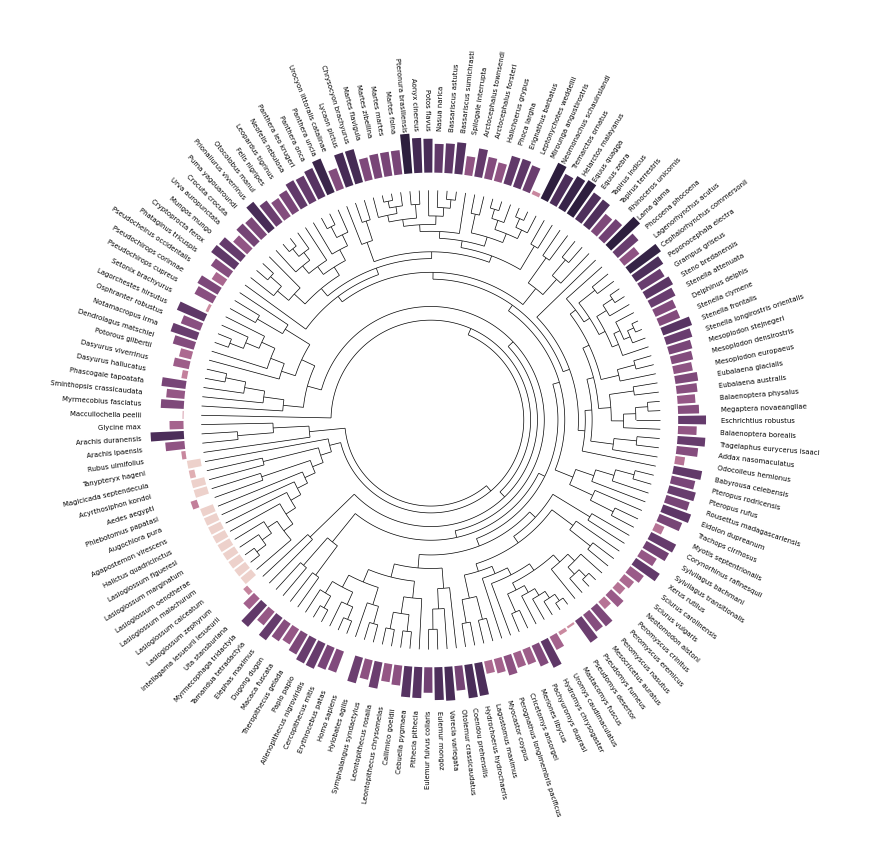

In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd
import seaborn as sns
import pickle
import numpy as np

methods = ['EvoHiC', 'HiCARN2']

def name_mapping(species):
    synonym = {
        'Herpailurus_yagouaroundi' : 'Puma_yagouaroundi',
        'Eulemur_collaris' : 'Eulemur_fulvus_collaris',
    }
    if species in synonym:
        return synonym[species]

    if '__' in species:
        return species.split('__')[0]

    return species
    

result = pd.read_csv(SPC_DNAZOO, sep='\t')
species_list = [name_mapping(s) for s in result['species'].tolist()]
improve = (result[methods[0]] - result[methods[1]]).tolist()
species2improve = dict(zip(species_list, improve))

from pycirclize import Circos
from collections import defaultdict
from pycirclize.utils import ColorCycler
from matplotlib.lines import Line2D
import math

tree_file = str(TREE_NWK)
circos, tv = Circos.initialize_from_tree(
    tree_file,
    start=-90,
    end=270,
    r_lim=(30, 80),
    leaf_label_rmargin=21,
    leaf_label_size=5,
    ignore_branch_length=True,
    label_formatter=lambda t: t.replace("_", " "),
)
#tv : TreeViz TreeViz instance pycirclize/tree.py
# claude_dir="/m-ent1/ent1/nobackup/dataset/hic_all/multi_species/claude/"
# claude_name_list=["Angiosperms","Protostomes","Amniota","Mammalia","Marsupialia"]
# group_name2species_list=defaultdict(list)

# for claude_index in range(5):
#     cur_claude=claude_name_list[claude_index]
#     cur_path=claude_dir+"claude%d_clean.txt"%(claude_index+1)
#     with open(cur_path,"r") as file:
#         for line in file:
#             cur_name=line.strip("\n")
#             group_name2species_list[cur_claude].append(cur_name)

# Set tree line color & label color

# ColorCycler.set_cmap("tab10")
# group_name2color = {name: ColorCycler() for name in group_name2species_list.keys()}
# for group_name, species_list in group_name2species_list.items():
#     color = group_name2color[group_name]
#     tv.set_node_line_props(species_list, color=color, apply_label_color=True)

## add bar

sector = circos.sectors[0]
bar_track = sector.add_track((80,100))
# matrix_data = np.random.randint(0, 100, (5, tv.leaf_num))
# heatmap_track.heatmap(matrix_data, cmap="viridis")
# heatmap_track.yticks([0.5, 1.5, 2.5, 3.5, 4.5], list("EDCBA"), vmax=5, tick_length=0)
species_list = tv.leaf_labels
#name2rad_dict=tv.name2rect
#height = [species2improve[x] for x in species_list if x in species2improve else 0]
height=[]
min_clip = -0.01
for x in species_list:
    if x in species2improve:
        cur_val =species2improve[x]
        cur_val=max(min_clip,cur_val)
        height.append(cur_val)
    else:
        print(x)
        height.append(0)
#rad_list=[name2rad_dict[x] for x in species_list]
percentile_98=np.percentile(height,98)
height=np.minimum(height,percentile_98)
start=-90
end=270
rad_list=[]
for k in range(len(species_list)):
    cur_angle= k/len(species_list)*360
    cur_rad=math.radians(start)+math.radians(cur_angle)
    rad_list.append(cur_rad)
rad_list=np.arange(0, int(len(species_list))) + 0.5
my_cmap = sns.cubehelix_palette(as_cmap=True)
rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))
print(np.max(height))
#bar_track.bar(rad_list, height, color=my_cmap(rescale(height)), ec="grey", lw=0.5, hatch="//")
#bar_track.axis()
bar_track.bar(rad_list, height, vmin=min_clip-0.003, color=my_cmap(rescale(height)))
# bar_track.yticks([0,0.03,0.06],labels=[0,0.03,0.06])
# Plot figure & set legend on center

fig = circos.plotfig()
_ = circos.ax.legend(
    # handles=[Line2D([], [], label=n, color=c) for n, c in group_name2color.items()],
    # labelcolor=group_name2color.values(),
    fontsize=10,
    loc="center",
    bbox_to_anchor=(0.5, 0.5),
)
#circos.savefig("evolution_circular_visualization.pdf",dpi=600)
plt.savefig(str(OUT_DIR / 'evolution_circular_improvement.pdf'))